# Multi-horizon demand forecasting — recursive trajectory prototype

**Purpose.** Today the system predicts only the **next hour** (h+1). That framing has little
business value: one hour is too short to act on (rebalancing needs 2–6h, staffing is
day-ahead). This notebook prototypes the change we're about to implement: predicting a
**trajectory** h+1…h+K (a demand profile) so the forecast can drive real operational
decisions, and produces per-horizon accuracy on a *realistic* serving setup.

**Design (already decided).**
- **Recursive, not direct.** We reuse the existing h+1 model unchanged and chain it: predict
  h+1, feed that prediction back as if it were the actual, predict h+2, and so on. The model
  is horizon-agnostic by construction — the horizon lives entirely in serving.
- **Full trajectory (policy B).** Each run emits and stores all of h+1…h+K. Every target hour
  ends up with K predictions, one per lead time, each measured separately.

**What this notebook establishes before touching `predict.py`:**
1. The recursive rollout mechanism, step by step, reusing the project's real feature functions.
2. How each future hour's **calendar** is handled (read the true value; never derive it from
   the shifted date) vs. its **weather** (unknown — approximated).
3. The **weather strategy** matters a lot at mid horizons — this notebook is what settled it.
4. Per-horizon skill vs. the seasonal-naive baseline on realistic serving.

## 1. Setup — load the real models, data, and feature functions

In [1]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

from bike_sharing.features.build_features import build_lag_features, build_calendar_features
from bike_sharing.utils.datetime_utils import reconstruct_datetime
from bike_sharing.models.train import FEATURES

# Config mirrors production (configs/features + configs/model)
LAGS = [1, 2, 3, 8, 24, 48, 72, 168]
ROLLING = [24, 168]
DROP_COLS = ["atemp", "cnt_lag_9", "cnt_lag_10", "season", "mnth_sin", "mnth_cos",
             "workingday", "holiday", "windspeed", "yr"]
CALENDAR_COLS = ["season", "yr", "mnth", "holiday", "weekday", "workingday"]
WEATHER_COLS = ["temp", "atemp", "hum", "windspeed"]

# The actual trained production models (same .txt files evaluate.py / the registry hold)
m_reg = lgb.Booster(model_file="../artifacts/models/lgbm_registered.txt")
m_cas = lgb.Booster(model_file="../artifacts/models/lgbm_casual.txt")

# Revealed history (what the system may look at)
past = reconstruct_datetime(pd.read_csv("../data/raw/hour_past.csv"))
past = past.sort_values("datetime").reset_index(drop=True)
min_date = past["dteday"].min()

# Calendar is knowable in advance, so we may read the true future calendar. NOT leakage —
# unlike weather. We index both past and future by datetime purely for the calendar lookup.
future = reconstruct_datetime(pd.read_csv("../data/raw/hour_future.csv"))
calendar_all = pd.concat([past, future], ignore_index=True).set_index("datetime")

# Actual demand + actual past weather, for scoring and for the lag24 weather strategy.
actual_map = past.set_index("datetime")["cnt"]
weather_map = past.set_index("datetime")[WEATHER_COLS]

print(f"past: {len(past):,} rows | {past['datetime'].min()} -> {past['datetime'].max()}")

/Users/robertogarces/miniforge3/envs/bike-sharing-forecast/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


past: 16,313 rows | 2024-08-17 00:00:00 -> 2026-07-04 10:00:00


## 2. The recursive rollout, step by step

To predict K hours ahead we build **one synthetic future hour at a time** and feed each
prediction back so the next step's lag features can use it. Two helpers:

- `make_raw_row` — builds the synthetic *raw* row for a target hour: the **true calendar**
  (read from `calendar_all`), the **weather** (per a strategy, see §3), and `cnt` unknown.
- `features_for` — runs that raw row through the project's **real** feature pipeline
  (`build_lag_features` + `build_calendar_features`), so the features are identical to
  training — no hand-written reimplementation that could silently diverge.

`predict_trajectory` then loops k = 1…K, and after each prediction appends the predicted row
to the working history so step k+1 sees it as `cnt_lag_1`.

In [2]:
def make_raw_row(work, target_dt, origin_weather, weather_mode):
    '''Synthetic raw row for target_dt: true calendar, weather per strategy, cnt unknown.

    weather_mode:
      "persist" -> carry the origin hour's weather across the whole horizon (naive).
      "lag24"   -> use the real weather from target-24h (same hour, previous day). Captures
                   the daily cycle and is available without leakage for horizons <= 24.
    '''
    row = work.iloc[-1].to_dict()
    row["datetime"] = target_dt
    row["dteday"] = target_dt.normalize()
    row["hr"] = target_dt.hour

    # Calendar: the true value for target_dt (knowable in advance). Never derive it from the
    # shifted dteday — the simulation's date shift breaks the real weekday/season alignment.
    if target_dt in calendar_all.index:
        for c in CALENDAR_COLS:
            row[c] = calendar_all.loc[target_dt, c]

    # Weather: genuinely unknown for the future, so approximated.
    lag24_dt = target_dt - pd.Timedelta(hours=24)
    if weather_mode == "lag24" and lag24_dt in weather_map.index:
        wsrc = weather_map.loc[lag24_dt]
        for c in WEATHER_COLS:
            row[c] = wsrc[c]
    else:
        for c in WEATHER_COLS:
            row[c] = origin_weather[c]

    row["cnt"] = np.nan
    row["registered"] = np.nan
    row["casual"] = np.nan
    return row


def features_for(work, raw_row):
    '''Feature row for raw_row, computed with the project's real feature functions.'''
    extended = pd.concat([work, pd.DataFrame([raw_row])], ignore_index=True)
    extended = build_lag_features(extended, lags=LAGS, rolling_windows=ROLLING)
    extended = build_calendar_features(extended, drop_cols=DROP_COLS, min_date=min_date)
    return extended.iloc[[-1]]


def predict_trajectory(work, horizon, weather_mode="lag24"):
    '''Recursive rollout: predict h+1..h+K from the last row of `work`, feeding each
    prediction back as a synthetic actual so the next step's lags use it.'''
    work = work.copy().sort_values("datetime").reset_index(drop=True)
    origin_dt = work.iloc[-1]["datetime"]
    origin_weather = work.iloc[-1][WEATHER_COLS]
    rows = []
    for k in range(1, horizon + 1):
        target_dt = origin_dt + pd.Timedelta(hours=k)
        raw_row = make_raw_row(work, target_dt, origin_weather, weather_mode)
        feat = features_for(work, raw_row)
        pred_reg = float(np.clip(np.expm1(m_reg.predict(feat[FEATURES])[0]), 0, None))
        pred_cas = float(np.clip(np.expm1(m_cas.predict(feat[FEATURES])[0]), 0, None))
        pred_total = pred_reg + pred_cas
        rows.append({"origin": origin_dt, "target": target_dt, "horizon": k,
                     "pred_registered": pred_reg, "pred_casual": pred_cas,
                     "pred_total": pred_total})
        # feed the prediction back as a synthetic actual for the next step
        raw_row["cnt"], raw_row["registered"], raw_row["casual"] = pred_total, pred_reg, pred_cas
        work = pd.concat([work, pd.DataFrame([raw_row])[work.columns]], ignore_index=True)
    return pd.DataFrame(rows)

### Watch one rollout happen

We pick an origin in the middle of the revealed history (so real actuals exist ahead to score
against) and roll forward 24 hours. Note how `pred_total` at each step becomes the `cnt_lag_1`
of the next — the model is literally reading its own previous prediction.

In [3]:
K = 24
origin_idx = len(past) - 200          # leave 200h of real "future" to compare against
work0 = past.iloc[: origin_idx + 1].copy()

traj = predict_trajectory(work0, K, weather_mode="lag24")
traj["actual"] = traj["target"].map(actual_map)

print(f"Origin (last known hour): {work0.iloc[-1]['datetime']}")
traj[["horizon", "target", "pred_total", "actual"]].round(1)

Origin (last known hour): 2026-06-26 03:00:00


,horizon,target,pred_total,actual
0,1,2026-06-26 04:00:00,4.6,14
1,2,2026-06-26 05:00:00,26.1,27
2,3,2026-06-26 06:00:00,120.2,131
3,4,2026-06-26 07:00:00,380.6,341
4,5,2026-06-26 08:00:00,647.3,693
5,6,2026-06-26 09:00:00,342.2,327
6,7,2026-06-26 10:00:00,190.7,197
7,8,2026-06-26 11:00:00,213.4,251
8,9,2026-06-26 12:00:00,267.3,262
9,10,2026-06-26 13:00:00,272.9,299


## 3. Calendar vs. weather — why they're handled differently

Both the calendar and the weather of a future hour are "unknown" in the sense that no row for
that hour has been revealed yet. But they are fundamentally different:

- **Calendar** (`workingday`, `season`, `mnth`, `holiday`, weekday) is *deterministically
  knowable* — next Monday is a working day whether or not it has "happened". We read the true
  value. Crucially we **do not** recompute it from the shifted `dteday`: the simulation shifts
  dates by a whole-day offset, so the real weekday of a shifted date no longer matches the
  original `workingday`/`weekday` the model trained on.
- **Weather** (`temp`, `hum`, `weathersit`) is *genuinely unknown* — reading the true future
  weather would be leakage (perfect foreknowledge no real system has). So it must be
  approximated. The next section shows the approximation choice is not cosmetic.

## 4. The weather strategy is a real decision (persist vs. lag24)

We compare two ways to fill the unknown future weather in the rollout, over many origins, and
score each horizon against the actuals — plus the **seasonal-naive** baseline (predict
`cnt(t-168)`, same hour last week) which is horizon-independent and is the bar the model must
clear to be worth anything.

- **persist**: carry the origin hour's weather across the whole horizon.
- **lag24**: use the real weather from 24h before each target (same hour, previous day).

This cell does a real recursive rollout per origin, so it takes ~1 minute.

In [4]:
rng = np.random.default_rng(0)
valid_max = len(past) - K - 1
origins = rng.choice(range(valid_max - 1200, valid_max), size=120, replace=False)

sq = {mode: {k: [] for k in range(1, K + 1)} for mode in ("persist", "lag24")}
sq_naive = {k: [] for k in range(1, K + 1)}

for oi in origins:
    w = past.iloc[: oi + 1].copy()
    for mode in ("persist", "lag24"):
        t = predict_trajectory(w, K, weather_mode=mode)
        actual = t["target"].map(actual_map)
        for k, a, p in zip(t["horizon"], actual, t["pred_total"]):
            if not np.isnan(a):
                sq[mode][int(k)].append((a - p) ** 2)
    origin_dt = w.iloc[-1]["datetime"]
    for k in range(1, K + 1):
        tgt = origin_dt + pd.Timedelta(hours=k)
        a, n = actual_map.get(tgt), actual_map.get(tgt - pd.Timedelta(hours=168))
        if a is not None and n is not None and not np.isnan(a) and not np.isnan(n):
            sq_naive[k].append((a - n) ** 2)


def rmse(vals):
    return float(np.sqrt(np.mean(vals))) if vals else np.nan


curve = pd.DataFrame({
    "horizon": range(1, K + 1),
    "persist": [rmse(sq["persist"][k]) for k in range(1, K + 1)],
    "lag24": [rmse(sq["lag24"][k]) for k in range(1, K + 1)],
    "naive": [rmse(sq_naive[k]) for k in range(1, K + 1)],
}).set_index("horizon")
curve["skill_lag24"] = 1 - curve["lag24"] / curve["naive"]
curve["skill_persist"] = 1 - curve["persist"] / curve["naive"]
curve.loc[[1, 2, 3, 6, 12, 24]].round(2)

,persist,lag24,naive,skill_lag24,skill_persist
horizon,,,,,
1,60.87,59.95,149.11,0.60,0.59
2,69.34,67.23,144.52,0.53,0.52
3,80.01,76.35,130.60,0.42,0.39
6,79.29,65.23,101.85,0.36,0.22
12,103.02,83.71,103.63,0.19,0.01
24,100.65,99.39,79.90,-0.24,-0.26


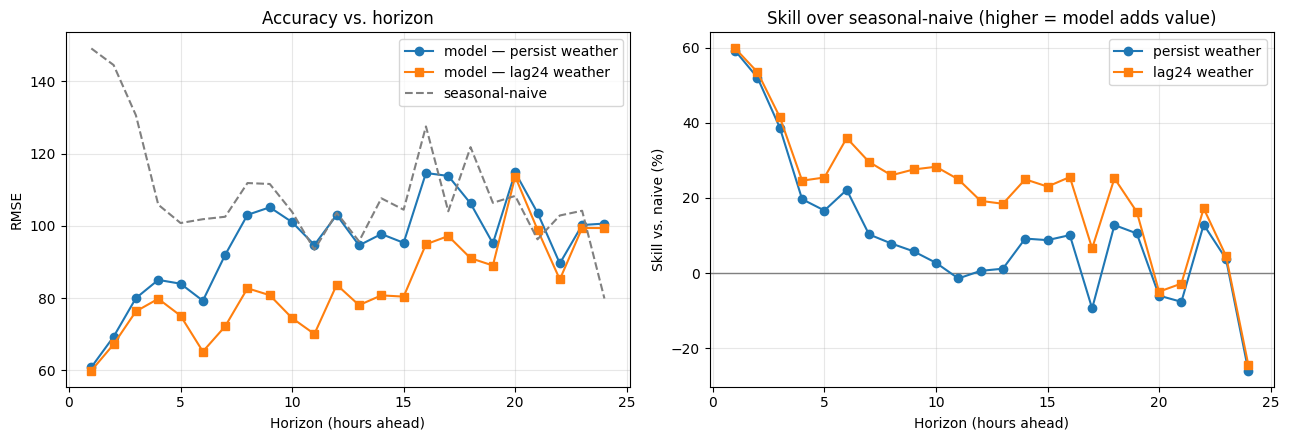

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(curve.index, curve["persist"], "o-", label="model — persist weather")
ax1.plot(curve.index, curve["lag24"], "s-", label="model — lag24 weather")
ax1.plot(curve.index, curve["naive"], "--", color="gray", label="seasonal-naive")
ax1.set_xlabel("Horizon (hours ahead)"); ax1.set_ylabel("RMSE")
ax1.set_title("Accuracy vs. horizon"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.axhline(0, color="gray", lw=1)
ax2.plot(curve.index, 100 * curve["skill_persist"], "o-", label="persist weather")
ax2.plot(curve.index, 100 * curve["skill_lag24"], "s-", label="lag24 weather")
ax2.set_xlabel("Horizon (hours ahead)"); ax2.set_ylabel("Skill vs. naive (%)")
ax2.set_title("Skill over seasonal-naive (higher = model adds value)")
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Reading it.** With naive weather persistence the model's edge over the trivial baseline
collapses at mid horizons — around h+12 it can actually do *worse* than seasonal-naive. Using
`lag24` weather (same hour, previous day) recovers most of that: the model stays above the
baseline across the whole range. The reason is physical — persisting the origin's weather 6–12
hours forward crosses into a very different part of the day (e.g. 3am temperature applied to
9am), while `lag24` respects the daily cycle.

**Decision for the implementation:** the recursive rollout uses **`lag24`** weather, falling
back to persistence only when `target-24h` isn't available (horizons > 24). A simulated
weather forecast is a possible future refinement; reading the true future weather is off the
table (leakage).

## 5. One trajectory, visualized

A single origin's predicted profile against what actually happened — this is the "demand
profile" an operator would consume to plan the next day.

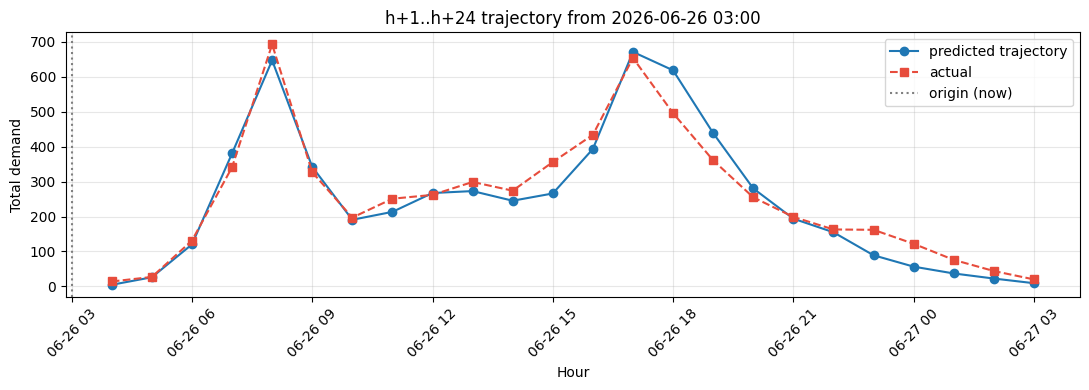

In [6]:
plt.figure(figsize=(11, 4))
plt.plot(traj["target"], traj["pred_total"], "o-", label="predicted trajectory")
plt.plot(traj["target"], traj["actual"], "s--", color="#E74C3C", label="actual")
plt.axvline(work0.iloc[-1]["datetime"], color="gray", ls=":", label="origin (now)")
plt.xlabel("Hour"); plt.ylabel("Total demand")
plt.title(f"h+1..h+{K} trajectory from {work0.iloc[-1]['datetime']:%Y-%m-%d %H:%M}")
plt.legend(); plt.grid(alpha=0.3); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 6. What the output schema looks like

Each hourly run emits **K rows** — one per lead time — sharing an origin. Over time each target
hour accumulates up to K predictions, one from each of the previous K origins, each at a
different `horizon`. That's why `predictions.csv` gains a `horizon` column and the dedup key
becomes `(timestamp_predicted, horizon)`, and why the monitoring is measured **per horizon**.

In [7]:
schema_preview = traj.assign(
    predicted_from=traj["origin"],
    timestamp_predicted=traj["target"],
).loc[:, ["predicted_from", "timestamp_predicted", "horizon",
          "pred_registered", "pred_casual", "pred_total"]]
schema_preview.head(6).round(1)

,predicted_from,timestamp_predicted,horizon,pred_registered,pred_casual,pred_total
0,2026-06-26 03:00:00,2026-06-26 04:00:00,1,4.2,0.4,4.6
1,2026-06-26 03:00:00,2026-06-26 05:00:00,2,25.7,0.4,26.1
2,2026-06-26 03:00:00,2026-06-26 06:00:00,3,117.9,2.3,120.2
3,2026-06-26 03:00:00,2026-06-26 07:00:00,4,368.4,12.2,380.6
4,2026-06-26 03:00:00,2026-06-26 08:00:00,5,628.3,18.9,647.3
5,2026-06-26 03:00:00,2026-06-26 09:00:00,6,318.4,23.9,342.2


## 7. Takeaways for the implementation

- The **recursive rollout works** end to end reusing the project's real feature functions —
  the model itself is untouched (it's the same h+1 model), so `train.py`, `evaluate.py`,
  `retrain.py`, promotion and the MLflow registry don't change.
- **Weather strategy = `lag24`** (same hour, previous day), not naive persistence — the
  difference between the model adding value and losing to a trivial baseline at mid horizons.
- **Calendar** for each future hour is read as the true value (never re-derived from the
  shifted date). Multi-horizon makes this a real requirement, not the dormant issue it was at
  h+1.
- The **useful horizon** is where the `lag24` skill line stays comfortably positive — read it
  off the chart above to choose the `horizon` (K) config value; there's no need to push K
  further than the model keeps beating the baseline.
- Output becomes **K rows per run** with a `horizon` column; monitoring is measured per
  horizon (the seasonal-naive baseline is horizon-independent, so it already fits).

The remaining honest caveat is weather: even `lag24` is an approximation, and a real system
would use a weather forecast. That's noted as a future refinement, not a blocker.